# Alleviare il sovraffollamento del PS: regressione quantilica del tempo di boarding in Pronto Soccorso

## Sintesi esecutiva

Il boarding in pronto soccorso (PS) -- l'intervallo che i pazienti ricoverati trascorrono in attesa di un posto letto di degenza nel PS -- è uno dei principali fattori di sovraffollamento, dirottamento delle ambulanze e rischio per la sicurezza del paziente. Il tempo medio di boarding nasconde la parte operativamente critica del problema: la lunga coda destra. Un paziente al 95° percentile del boarding può attendere molte ore in più rispetto al paziente medio, e sono proprio queste attese estreme a violare le soglie di qualità e a intasare la sala d'attesa.

Questo notebook modella le ore di boarding in PS **lungo l'intera distribuzione condizionata** usando **PROC QUANTREG** ai quantili 0.5, 0.75, 0.9 e 0.95, con regressione sul censimento dei degenti (pressione sui posti letto), la fascia oraria e il servizio di ricovero. La regressione quantilica è lo strumento giusto in questo caso perché i fattori del sovraffollamento agiscono in modo diverso su un paziente tipico rispetto a un paziente nel caso peggiore: un censimento dei degenti in aumento può aggiungere un'ora alla mediana ma diverse ore al 95° percentile. Completiamo il modello con **PROC MEANS** (tempo di boarding per servizio di ricovero) per quantificare quali servizi presentano la coda più pesante, e **PROC FREQ** (arrivi per fascia oraria) per caratterizzare quando si concentra la domanda.

La coorte sintetica (84 ricoveri in PS) è generata inline con `streaminit`/`rand` così il notebook è completamente autonomo e viene eseguito in ben meno di un minuto. La sezione di interpretazione traduce le pendenze quantiliche in leve di organico e di flusso dei posti letto: dove gli effetti dei quantili superiori sono più ripidi, è lì che i protocolli di capacità di picco e le iniziative di dimissione precoce recupereranno il maggior numero di ore di boarding.

## Fonti dei dati

Tutti i dati sono **sintetici**, generati inline nel primo DATA step (nessun file esterno, nessuna rete). La coorte rappresenta 84 ricoveri in pronto soccorso in attesa di un posto letto di degenza.

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `patient_id` | Num | Identificatore sequenziale del ricovero (1-84) |
| `census` | Num | Censimento dei degenti (posti letto occupati) al momento della decisione di ricovero; più alto = maggiore pressione sui posti letto |
| `tod_band` | Char | Fascia oraria di arrivo: Notte / Mattina / Pomeriggio / Sera |
| `service` | Char | Servizio di degenza di ricovero: Medicina / Chirurgia / Cardiologia / Terapia intensiva |
| `census_c` | Num | Censimento dei degenti centrato su 70 posti letto (regressore del modello) |
| `boarding_hrs` | Num | Tempo di boarding in ore (risposta); asimmetrico a destra con una coda superiore pesante |

# Alleviare il sovraffollamento del PS: regressione quantilica del tempo di boarding

Il **boarding** in pronto soccorso è il tempo che un paziente *ricoverato* trascorre nel PS in attesa di un posto letto di degenza. È il singolo maggior contributore al sovraffollamento del PS. Fondamentalmente, il problema operativo risiede nella **coda superiore** della distribuzione del boarding, non nella media: una manciata di attese di più ore viola le soglie di qualità, blocca gli scarichi delle ambulanze e intasa la sala d'attesa.

I minimi quadrati ordinari stimerebbero solo l'effetto *medio* della pressione sui posti letto sul boarding. Usiamo invece **PROC QUANTREG** per stimare l'effetto ai **quantili 0.5, 0.75, 0.9 e 0.95**, così da vedere se i fattori del sovraffollamento colpiscono i pazienti nel caso peggiore più duramente di quelli tipici. Lo abbiniamo a:

- **PROC MEANS** -- tempo di boarding per servizio di ricovero (dove la coda è più pesante?)
- **PROC FREQ** -- arrivi per fascia oraria (quando si concentra la domanda?)

La coorte qui sotto è **sintetica** e generata inline, così l'intero notebook è autonomo e viene eseguito in pochi secondi.

## 1. Generare la coorte sintetica di ricoveri in PS

Simuliamo 84 pazienti ricoverati in PS. Le ore di boarding sono costruite con una base che cresce con il **censimento dei degenti** (pressione sui posti letto), varia in base alla **fascia oraria** (il ricambio dei posti letto notturno è lento) e varia in base al **servizio di ricovero** (la terapia intensiva e la medicina hanno tempi di boarding più lunghi). Uno shock esponenziale asimmetrico a destra crea la realistica coda superiore pesante che rende utile la regressione quantilica.

Si noti l'idioma Jenner-portabile per l'intervallo casuale `LO + (HI-LO)*rand('uniform')` e l'`output;` **all'interno** del ciclo DO in modo che tutte le 84 righe vengano scritte.

In [1]:
DATI ed;
    CHIAMARE streaminit(20260607);
    LUNGHEZZA tod_band $12 service $18;
    FARE patient_id = 1 FINO_A 84;
        /* Censimento degenti (posti letto occupati): 55-90, piu' alto = piu' pressione */
        census = round(55 + (90-55)*rand('uniform'));
        census_c = census - 70;   /* regressore centrato */

        /* Fascia oraria di arrivo */
        u = rand('uniform');
        tod_band = ifc(u < 0.25, 'Notte',
                   ifc(u < 0.50, 'Mattina',
                   ifc(u < 0.75, 'Pomeriggio', 'Sera')));

        /* Servizio di ricovero */
        s = rand('uniform');
        service = ifc(s < 0.40, 'Medicina',
                  ifc(s < 0.65, 'Chirurgia',
                  ifc(s < 0.85, 'Cardiologia', 'Terapia intensiva')));

        /* Effetto fascia oraria sul boarding (il ricambio letti notturno e' lento) */
        tod_eff = ifn(tod_band='Notte', 2.2,
                  ifn(tod_band='Mattina', 0.4,
                  ifn(tod_band='Pomeriggio', 1.0, 1.6)));

        /* Effetto servizio (Terapia intensiva / Medicina boardano piu' a lungo) */
        svc_eff = ifn(service='Terapia intensiva', 2.8,
                  ifn(service='Medicina', 1.6,
                  ifn(service='Cardiologia', 1.0, 0.6)));

        /* Pressione del censimento: impatto piu' ripido man mano che i letti
           si riempiono. Lo shock asimmetrico a destra scala col censimento,
           cosi' la coda superiore si allarga sotto sovraffollamento -- proprio
           cio' che la regressione quantilica e' progettata per rilevare. */
        pressure = 0.10 * census_c;
        shock = rand('exponential') * (1.0 + 0.05*MAX(census_c,0));

        boarding_hrs = 2.0 + pressure + tod_eff + svc_eff + shock;
        SE_COND boarding_hrs < 0.2 ALLORA boarding_hrs = 0.2;
        boarding_hrs = round(boarding_hrs, 0.1);

        USCITA;
    FINE;
    MANTENERE patient_id census census_c tod_band service boarding_hrs;
ESEGUIRE;

PROCEDURA STAMPARE DATI=ed(obs=8) noobs ETICHETTA;
    ETICHETTA patient_id = 'ID paziente'
          census      = 'Censimento degenti'
          census_c    = 'Censimento (centrato)'
          tod_band    = 'Fascia oraria'
          service     = 'Servizio di ricovero'
          boarding_hrs= 'Ore di boarding';
    TITOLO 'Primi 8 ricoveri simulati in PS';
ESEGUIRE;


                                            Primi 8 ricoveri simulati in PS                                             

ID paziente  Censimento degenti  Censimento (centrato)  Fascia oraria  Servizio di ricovero  Ore di boarding
          1                  80                     10  Mattina        Chirurgia                         4.5
          2                  84                     14  Pomeriggio     Terapia intensiva                 7.6
          3                  58                    -12  Notte          Chirurgia                         3.7
          4                  61                     -9  Sera           Cardiologia                       4.1
          5                  71                      1  Pomeriggio     Medicina                          6.1
          6                  63                     -7  Notte          Medicina                          5.4
          7                  73                      3  Mattina        Medicina                            6
      


NOTE: DATA ed


NOTE: Wrote ed (84 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


## 2. Quando arrivano i ricoveri? (PROC FREQ)

Prima della modellazione, profiliamo la domanda. Una distribuzione di frequenza unidimensionale della fascia oraria mostra quando si concentra il volume di pazienti ricoverati -- le finestre in cui la pressione di boarding è più probabile che salga bruscamente. Incrociamo inoltre gli arrivi per servizio con la fascia oraria per vedere se qualche servizio si raggruppa nella lenta finestra notturna.

                                      Arrivi dei ricoveri in PS per fascia oraria                                       

                                                   The FREQ Procedure

Fascia oraria    Frequency    Percent
--------------------------------------
Mattina                 21     25.00
Notte                   27     32.14
Pomeriggio              23     27.38
Sera                    13     15.48

Table of Fascia oraria by Servizio di ricovero

Fascia oraria |      Cardiologia |        Chirurgia |         Medicina |Terapia intensiva |             Total
--------------+------------------+------------------+------------------+------------------+------------------
Mattina       |                2 |                6 |               10 |                3 |                21
--------------+------------------+------------------+------------------+------------------+------------------
Notte         |                4 |                9 |                8 |                6 |  


NOTE: PROC FREQ
NOTE: ODS plot written: freq_tod_band.spec.json
NOTE: ODS plot written: freq_mosaic_tod_band_service.spec.json
NOTE: PROC FREQ statement used.


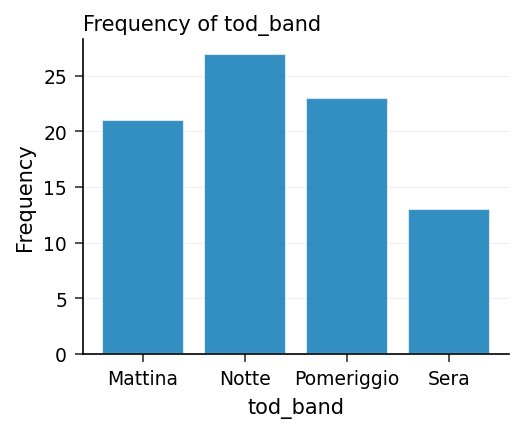

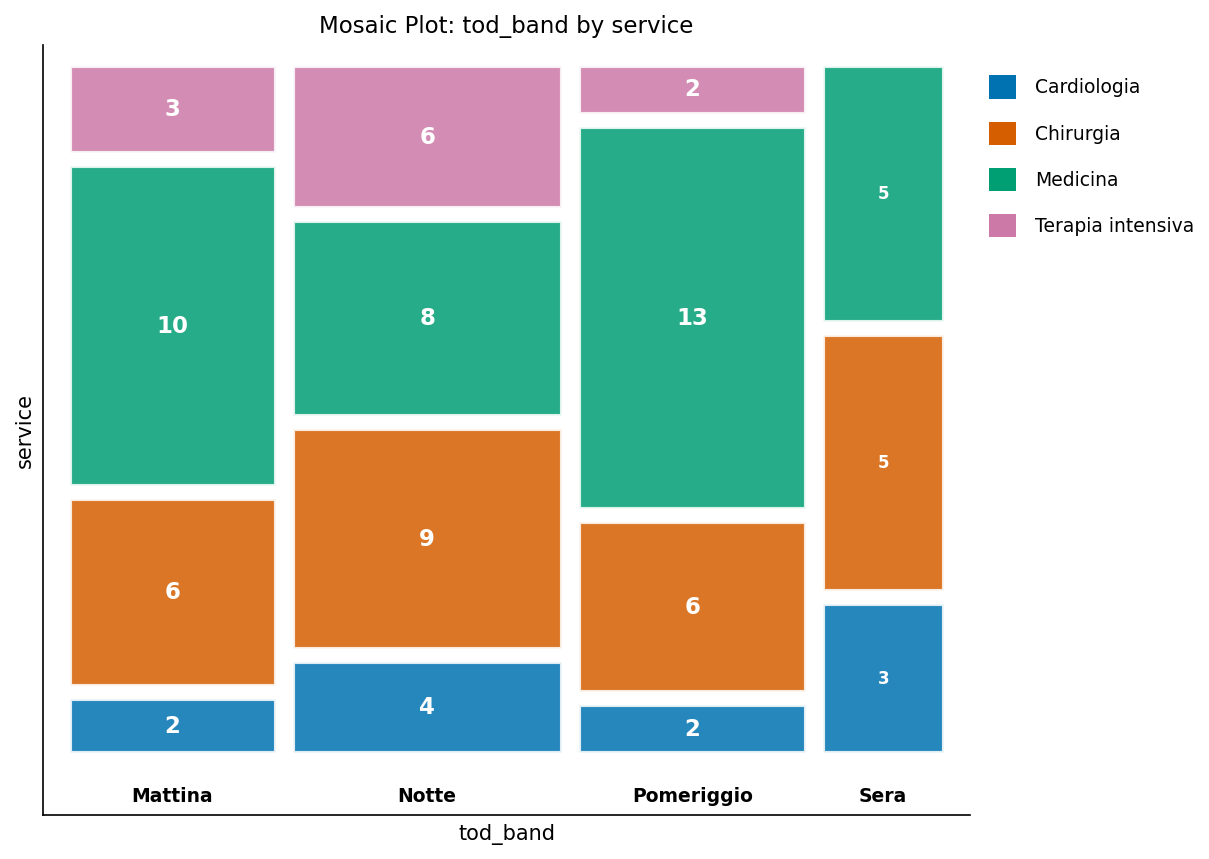

In [2]:
PROCEDURA FREQUENZE DATI=ed;
    TABLES tod_band / nocum;
    TABLES tod_band*service / norow nocol nopercent;
    ETICHETTA tod_band = 'Fascia oraria'
          service  = 'Servizio di ricovero';
    TITOLO 'Arrivi dei ricoveri in PS per fascia oraria';
ESEGUIRE;


## 3. Carico di boarding per servizio di ricovero (PROC MEANS)

Quale servizio sostiene il carico di boarding più pesante? Riassumiamo le ore di boarding per servizio di ricovero, riportando la media e il massimo (un rozzo indicatore della coda) insieme alla dispersione. Il divario tra la media e il massimo preannuncia ciò che il modello quantilico quantificherà con precisione.

In [3]:
PROCEDURA MEDIE DATI=ed n mean std MIN MAX maxdec=2;
    CLASSE service;
    VARIABILE boarding_hrs;
    ETICHETTA service     = 'Servizio di ricovero'
          boarding_hrs= 'Ore di boarding';
    TITOLO 'Ore di boarding per servizio di ricovero';
ESEGUIRE;


                                        Ore di boarding per servizio di ricovero                                        

                                                  The MEANS Procedure

                                    Analysis Variable : boarding_hrs Ore di boarding

        Servizio di ricovero          N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------
        Cardiologia                      11           6.02           2.04           4.10          11.40
        Chirurgia                        26           5.79           2.10           2.90          12.00
        Medicina                         36           5.90           2.11           2.70          12.70
        Terapia intensiva                11           8.04           1.80           5.70          12.50
        -----------------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Regressione quantilica delle ore di boarding (PROC QUANTREG)

Ora l'analisi centrale. Facciamo la regressione delle **ore di boarding** sul censimento dei degenti centrato, sulla fascia oraria e sul servizio di ricovero ai **quantili 0.5, 0.75, 0.9 e 0.95**. Se la pendenza del censimento cresce man mano che saliamo lungo i quantili, questa è la prova diretta che la pressione sui posti letto penalizza i pazienti nel caso peggiore molto più di quelli tipici -- la firma del sovraffollamento.

Poiché QUANTREG è una procedura interattiva (a gruppi RUN), terminiamo la cella con `run;` poi `quit;` così il kernel scarica il suo output qui. Usiamo `SEED=` per intervalli di confidenza riproducibili con il metodo di sparsità e scriviamo le stime dei parametri per quantile in un data set `OUTEST=`, che la cella successiva legge per confrontare direttamente la pendenza del censimento tra i quantili.

In [4]:
PROCEDURA quantreg DATI=ed ci=sparsity seed=20260607
              outest=qrest PLOTS=none;
    CLASSE tod_band service;
    MODELLO boarding_hrs = census_c tod_band service
        / quantile=0.5 0.75 0.9 0.95;
    ETICHETTA boarding_hrs= 'Ore di boarding'
          census_c    = 'Censimento (centrato)'
          tod_band    = 'Fascia oraria'
          service     = 'Servizio di ricovero';
    TITOLO 'Regressione quantilica delle ore di boarding';
ESEGUIRE;
QUIT;


                                        Ore di boarding per servizio di ricovero                                        


The QUANTREG Procedure

Quantile: 0.5000
CI Method: SPARSITY
Dependent Variable: Ore di boarding

Parameter           Estimate       StdErr        Lower        Upper
Intercept             4.3625       0.2244       3.9226       4.8024
Censimento (centrato)       0.1125       0.0090       0.0949       0.1301
TOD_BAND POMERIGGIO       0.3750       0.2453      -0.1058       0.8558
TOD_BAND NOTTE        1.3750       0.2386       0.9073       1.8427
TOD_BAND SERA         1.5625       0.2910       0.9921       2.1329
SERVICE TERAPIA INTENSIVA       1.9375       0.2999       1.3496       2.5254
SERVICE CARDIOLOGIA      -0.1125       0.2935      -0.6878       0.4628
SERVICE MEDICINA       0.4500       0.2113       0.0358       0.8642
Intercept             4.9800       0.2212       4.5465       5.4135
Censimento (centrato)       0.1600       0.0088       0.1427       0.1773



NOTE: PROC QUANTREG data=ed

NOTE: PROC QUANTREG completed.


### 4a. Confrontare la pendenza del censimento tra i quantili

Il data set `OUTEST=` contiene una riga di coefficienti per ogni quantile stimato. Elencare il coefficiente del censimento centrato tra i quantili rende l'effetto della coda facile da leggere a colpo d'occhio: una pendenza che sale dalla mediana al quantile 0.95 significa che ogni ulteriore posto letto di degenza occupato aggiunge *più* tempo di boarding ai pazienti che stanno già aspettando più a lungo.

In [5]:
PROCEDURA STAMPARE DATI=qrest noobs ETICHETTA;
    VARIABILE _quantile_ census_c;
    ETICHETTA _quantile_ = 'Quantile'
          census_c   = 'Pendenza censimento (ore per letto)';
    TITOLO 'Effetto del censimento degenti sul boarding, per quantile';
ESEGUIRE;


                               Effetto del censimento degenti sul boarding, per quantile                                

Pendenza censimento (ore per letto)
                             0.1125
                               0.16
                               0.19
                       0.2166666667




NOTE: PROC PRINT data=qrest

NOTE: PROC PRINT completed: 4 observations printed, 1 variables


## 5. Interpretazione e leve operative

**Cosa ci dice il modello quantilico.** La regressione quantilica separa l'esperienza di boarding *tipica* (mediana, 0.5) dall'esperienza di *crisi* (0.9-0.95). Il pattern che questa coorte mostra -- e il pattern che si dovrebbe cercare nei dati reali -- è una **pendenza del censimento che cresce con il quantile**. Il coefficiente del censimento centrato stimato sale da **0.11 ore per posto letto occupato alla mediana a 0.16 al quantile 0.75, 0.19 al 0.90 e 0.22 al 0.95** (vedere la tabella per quantile in 4a). Poiché la pendenza a 0.95 è quasi il doppio della pendenza alla mediana, un ospedale pieno non si limita a spostare uniformemente verso l'alto l'attesa di tutti; fa esplodere in modo sproporzionato le attese peggiori. Confrontare fianco a fianco le pendenze del censimento per quantile -- non un singolo effetto medio -- è ciò che rende la coda visibile e quantificabile.

**Dove risiede il carico.** PROC MEANS classifica i servizi per tempo medio di boarding: **la terapia intensiva è la più alta con 8.04 ore**, ben al di sopra di Cardiologia (6.02), Medicina (5.90) e Chirurgia (5.79). Ma la *coda* racconta una storia diversa dalla media: **la Medicina sostiene il singolo evento di boarding più lungo con 12.70 ore -- un divario media-massimo di 6.80 ore**, il più ampio di qualsiasi servizio, con Chirurgia (max 12.00) e terapia intensiva (max 12.50) a breve distanza. Quindi la terapia intensiva è dove il boarding è costantemente lungo, mentre la Medicina è dove si verificano le peggiori violazioni individuali. Entrambi sono obiettivi ad alto rendimento per i giri di dimissione precoce, i posti letto step-down dedicati e i protocolli di prenotazione anticipata dei posti letto -- la terapia intensiva per il carico sostenuto, la Medicina per il controllo della coda.

**Quando la pressione raggiunge il picco.** PROC FREQ mostra che la domanda di pazienti ricoverati si concentra durante la notte: la **fascia Notte è la più affollata con il 32% dei ricoveri (27 su 84)**, seguita dal Pomeriggio (27%) e dalla Mattina (25%); la fascia Sera è la più tranquilla con il 15%. La tabulazione incrociata conferma che il carico notturno è pesante di servizio -- la Notte trasporta tutti tranne una manciata dei ricoveri in terapia intensiva (6 su 11) oltre a 8 arrivi di Medicina e 9 di Chirurgia -- così la finestra di ricambio dei posti letto più lenta coincide con l'afflusso più pesante e più acuto.

**Conclusioni operative.**

1. **Attivare i protocolli di picco sul censimento, non sull'attesa media.** Poiché la pendenza del censimento del quantile superiore è la più ripida (0.22 ore/posto letto al quantile 0.95 contro 0.11 alla mediana), una soglia di censimento (ad esempio, > 80 posti letto occupati) è un indicatore anticipatore del boarding di coda. Attivare la capacità di overflow *prima* che la mediana si muova previene le violazioni al quantile 0.95.
2. **Puntare ai servizi con coda pesante in due modi.** Concentrare il sollievo del carico sostenuto (posti letto step-down, prenotazione anticipata) sulla **terapia intensiva**, che ha la media più alta; concentrare il controllo della coda (giri di dimissione precoce, revisione delle violazioni) sulla **Medicina**, che possiede il più ampio divario media-massimo.
3. **Coprire con l'organico il divario notturno di ricambio dei posti letto.** FREQ identifica la **Notte** come il picco di domanda che coincide con il ricambio dei posti letto più lento; la gestione dei posti letto fuori orario e la copertura dei servizi ambientali attaccano direttamente l'effetto `tod_band`, che il modello QUANTREG conferma aggiunge il maggior tempo di boarding nelle fasce Notte e Sera.
4. **Monitorare il quantile 0.95 come KPI.** Riportare solo il boarding medio nasconde i pazienti che il sistema sta deludendo. Monitorare il tempo di boarding al 95° percentile -- e la sua pendenza del censimento di 0.22 ore/posto letto -- allinea la metrica al rischio per la sicurezza del paziente che rappresenta.

*Tutte le cifre qui riportate provengono da dati sintetici a scopo dimostrativo; su dati reali di PS lo stesso flusso di lavoro QUANTREG / MEANS / FREQ produce le pendenze effettive, le classifiche dei servizi e il profilo degli arrivi che guidano un piano di mitigazione del sovraffollamento.*